In [1]:
# =========================
# BASIC LIBRARIES
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import random
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')

# =========================
# DEEP LEARNING (TENSORFLOW - ALEXNET)
# =========================
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications.efficientnet import preprocess_input  # keep if used elsewhere

# =========================
# SKLEARN (EVALUATION + METRICS)
# =========================
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    matthews_corrcoef,
    cohen_kappa_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

from sklearn.inspection import permutation_importance, partial_dependence
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA

# =========================
# EXPLAINABILITY
# =========================
import shap
import lime
import lime.lime_image  # IMPORTANT (you missed this for image LIME)
import lime.lime_tabular

from skimage.segmentation import mark_boundaries

# =========================
# COMPUTER VISION
# =========================
import cv2

# =========================
# UTILITIES
# =========================
from tqdm import tqdm

# =========================
# SEEDING (REPRODUCIBILITY)
# =========================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("All imports loaded successfully ✔")

2026-05-11 15:32:42.617952: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778513562.970916      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778513563.087480      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778513563.938646      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778513563.938684      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778513563.938687      57 computation_placer.cc:177] computation placer alr

All imports loaded successfully ✔


# EDA

In [2]:
BASE_PATH = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"
CSV_PATH = os.path.join(BASE_PATH, "Data_Entry_2017.csv")

image_paths = {}
for root, _, files in os.walk(BASE_PATH):
    for file in files:
        if file.lower().endswith(".png"):
            image_paths[file] = os.path.join(root, file)

print("Total images found:", len(image_paths))

df = pd.read_csv(CSV_PATH)
print("Metadata shape:", df.shape)
df.head()


Total images found: 112120
Metadata shape: (112120, 12)


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [3]:
df = df.copy()

if "View Position" in df.columns:
    df = df[df["View Position"].isin(["PA", "AP"])].copy()

df = df[
    (df["Finding Labels"] == "No Finding") |
    (df["Finding Labels"].str.contains("Pneumonia", na=False))
].copy()

df["label"] = df["Finding Labels"].apply(lambda x: 1 if "Pneumonia" in x else 0)
df["path"] = df["Image Index"].map(image_paths)

keep_cols = ["Image Index", "Finding Labels", "label", "path"]
if "Patient ID" in df.columns:
    keep_cols.append("Patient ID")
if "View Position" in df.columns:
    keep_cols.append("View Position")

df = df[keep_cols].dropna(subset=["path"]).drop_duplicates().reset_index(drop=True)

print("Filtered dataset shape:", df.shape)
print(df["label"].value_counts())
df.head()


Filtered dataset shape: (61792, 6)
label
0    60361
1     1431
Name: count, dtype: int64


,Image Index,Finding Labels,label,path,Patient ID,View Position
0,00000002_000.png,No Finding,0,/kaggle/input/datasets/organizations/nih-chest...,2,PA
1,00000005_000.png,No Finding,0,/kaggle/input/datasets/organizations/nih-chest...,5,PA
2,00000005_001.png,No Finding,0,/kaggle/input/datasets/organizations/nih-chest...,5,AP
3,00000005_002.png,No Finding,0,/kaggle/input/datasets/organizations/nih-chest...,5,AP
4,00000005_003.png,No Finding,0,/kaggle/input/datasets/organizations/nih-chest...,5,PA


In [4]:
df['Finding Labels'].value_counts()

Finding Labels
No Finding                                                  60361
Pneumonia                                                     322
Infiltration|Pneumonia                                        199
Edema|Infiltration|Pneumonia                                  137
Atelectasis|Pneumonia                                         108
                                                            ...  
Mass|Nodule|Pneumonia|Pneumothorax                              1
Atelectasis|Effusion|Infiltration|Pneumonia|Pneumothorax        1
Cardiomegaly|Consolidation|Effusion|Pneumonia                   1
Consolidation|Nodule|Pneumonia                                  1
Consolidation|Pneumonia|Mass                                    1
Name: count, Length: 143, dtype: int64

In [5]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nUnique patients:", df["Patient ID"].nunique() if "Patient ID" in df.columns else "Patient ID not found")
print("Unique images:", df["Image Index"].nunique())
print("\nClass distribution:")
print(df["label"].value_counts(normalize=True).rename("ratio"))


Missing values per column:
Image Index       0
Finding Labels    0
label             0
path              0
Patient ID        0
View Position     0
dtype: int64

Unique patients: 25052
Unique images: 61792

Class distribution:
label
0    0.976842
1    0.023158
Name: ratio, dtype: float64


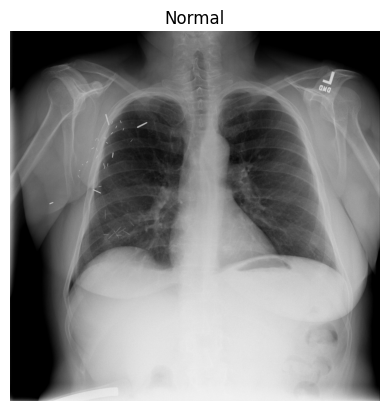

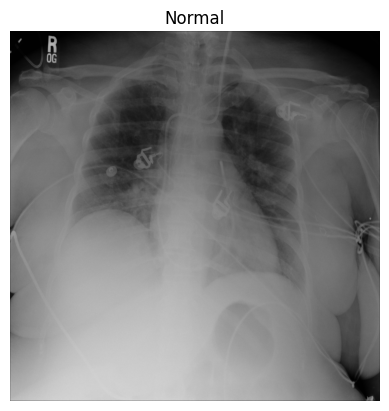

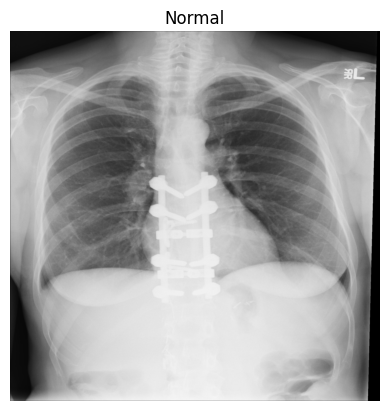

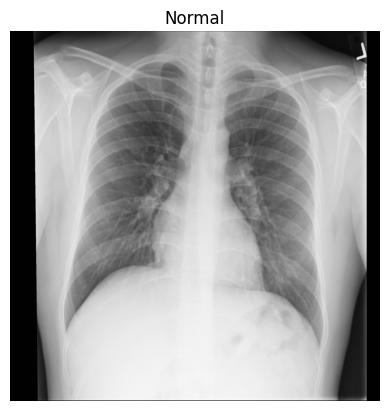

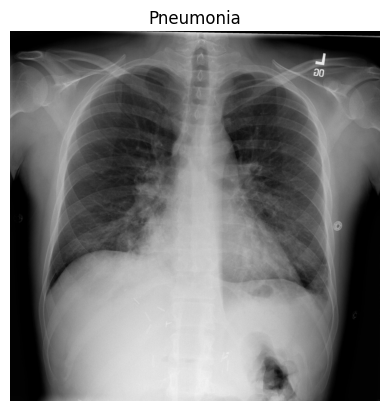

In [6]:
import cv2
import matplotlib.pyplot as plt

sample = df.sample(5)

for _, row in sample.iterrows():
    img = cv2.imread(row["path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.title("Pneumonia" if row["label"] == 1 else "Normal")
    plt.axis("off")
    plt.show()

In [7]:
print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Duplicates after:", df.duplicated().sum())

if "Patient ID" in df.columns:
    patient_level = df.groupby("Patient ID")["label"].max().value_counts()
    print("\nPatient-level label distribution:")
    print(patient_level)

print("\nImage-level label distribution:")
print(df["label"].value_counts())


Duplicates before: 0
Duplicates after: 0

Patient-level label distribution:
label
0    24044
1     1008
Name: count, dtype: int64

Image-level label distribution:
label
0    60361
1     1431
Name: count, dtype: int64


label
0    60361
1     1431
Name: count, dtype: int64
(61792, 6)


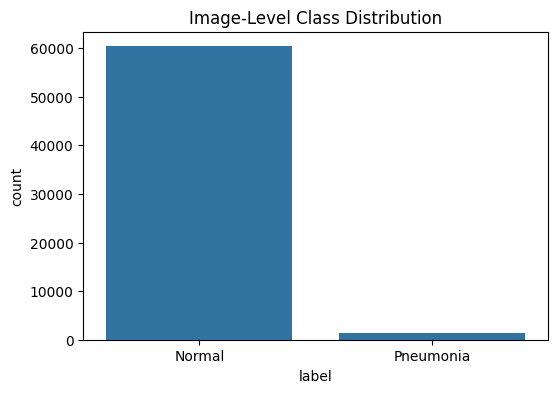

In [8]:
df_model = df.copy().reset_index(drop=True)

print(df_model["label"].value_counts())
print(df_model.shape)

plt.figure(figsize=(6, 4))
sns.countplot(x=df_model["label"])
plt.xticks([0, 1], ["Normal", "Pneumonia"])
plt.title("Image-Level Class Distribution")
plt.show()


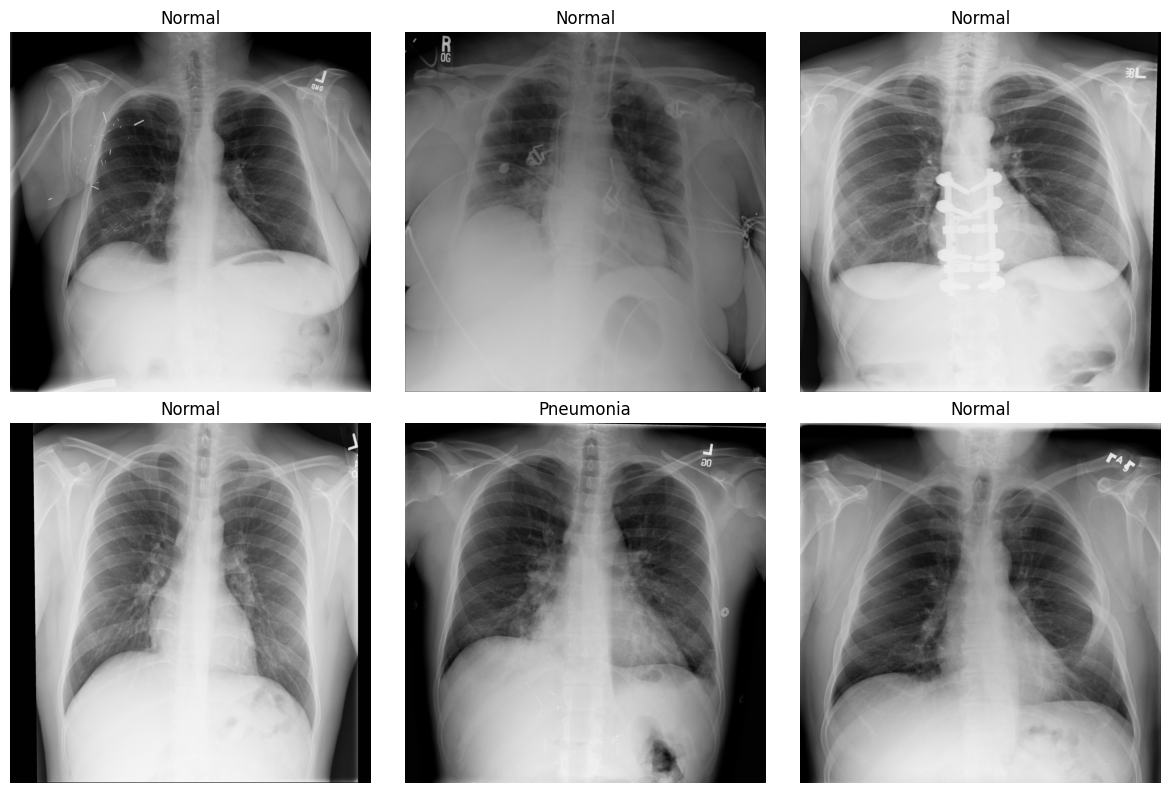

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
samples = df_model.sample(6, random_state=42).reset_index(drop=True)

for i, ax in enumerate(axes.flat):
    img = cv2.imread(samples.loc[i, "path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title("Pneumonia" if samples.loc[i, "label"] == 1 else "Normal")
    ax.axis("off")

plt.tight_layout()
plt.show()


In [10]:
sizes = []

for p in df_model["path"].sample(min(200, len(df_model)), random_state=42):
    img = cv2.imread(p)
    if img is not None:
        sizes.append(img.shape[:2])

sizes_df = pd.DataFrame(sizes, columns=["Height", "Width"])
sizes_df.describe()


,Height,Width
count,200.0,200.0
mean,1024.0,1024.0
std,0.0,0.0
min,1024.0,1024.0
25%,1024.0,1024.0
50%,1024.0,1024.0
75%,1024.0,1024.0
max,1024.0,1024.0


In [11]:
assert "Patient ID" in df_model.columns, "Patient ID column is required for patient-level split."

patient_labels = df_model.groupby("Patient ID")["label"].max().reset_index()

train_pat, temp_pat = train_test_split(
    patient_labels,
    test_size=0.30,
    stratify=patient_labels["label"],
    random_state=SEED
)

val_pat, test_pat = train_test_split(
    temp_pat,
    test_size=0.50,
    stratify=temp_pat["label"],
    random_state=SEED
)

train_df = df_model[df_model["Patient ID"].isin(train_pat["Patient ID"])].copy()
val_df   = df_model[df_model["Patient ID"].isin(val_pat["Patient ID"])].copy()
test_df  = df_model[df_model["Patient ID"].isin(test_pat["Patient ID"])].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain label counts:")
print(train_df["label"].value_counts())
print("\nValidation label counts:")
print(val_df["label"].value_counts())
print("\nTest label counts:")
print(test_df["label"].value_counts())

assert set(train_df["Patient ID"]).isdisjoint(set(val_df["Patient ID"]))
assert set(train_df["Patient ID"]).isdisjoint(set(test_df["Patient ID"]))
assert set(val_df["Patient ID"]).isdisjoint(set(test_df["Patient ID"]))
print("\nNo patient leakage detected.")


Train: (43018, 6)
Validation: (9271, 6)
Test: (9503, 6)

Train label counts:
label
0    42043
1      975
Name: count, dtype: int64

Validation label counts:
label
0    9070
1     201
Name: count, dtype: int64

Test label counts:
label
0    9248
1     255
Name: count, dtype: int64

No patient leakage detected.


In [12]:
from sklearn.utils.class_weight import compute_class_weight
classes = np.array([0, 1])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].values
)

class_weights = {
    0: float(weights[0]),
    1: float(weights[1])
}

print(class_weights)


{0: 0.5115952715077421, 1: 22.06051282051282}


Original TRAIN distribution:
Counter({0: 42043, 1: 975})


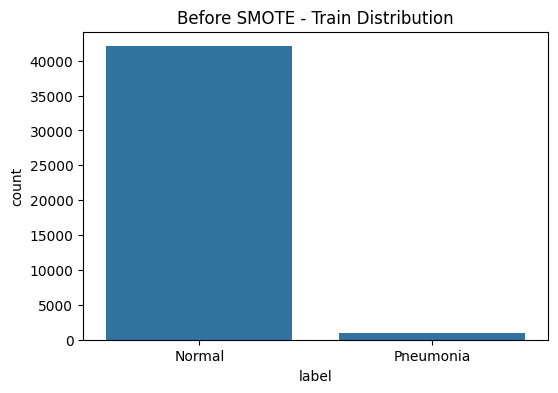


After SMOTE:
Counter({0: 42043, 1: 21021})


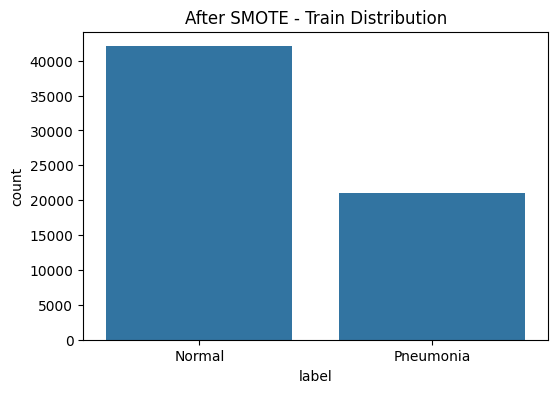


Final image-train distribution:
label
0    42043
1    21021
Name: count, dtype: int64


In [13]:
# =========================
# CLASS IMBALANCE REVIEW
# =========================
from collections import Counter
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

print("Original TRAIN distribution:")
print(Counter(train_df["label"]))

plt.figure(figsize=(6,4))
sns.countplot(x=train_df["label"])
plt.xticks([0,1], ["Normal", "Pneumonia"])
plt.title("Before SMOTE - Train Distribution")
plt.show()


# ==========================================================
# FEATURE PREP FOR SMOTE
# ==========================================================
# Since SMOTE cannot use image paths directly,
# we use structured metadata for balancing support
# (Age + Gender + View Position)
# ==========================================================

smote_train = train_df.copy()

# Gender
if "Patient Gender" in df.columns:
    gender_map = df[["Image Index", "Patient Gender"]].drop_duplicates()
    gender_map["Patient Gender"] = gender_map["Patient Gender"].map({"M":0, "F":1})
    smote_train = smote_train.merge(
        gender_map,
        on="Image Index",
        how="left"
    )
else:
    smote_train["Patient Gender"] = 0

# Age
if "Patient Age" in df.columns:
    age_map = df[["Image Index", "Patient Age"]].drop_duplicates()
    smote_train = smote_train.merge(
        age_map,
        on="Image Index",
        how="left"
    )
else:
    smote_train["Patient Age"] = 50

# View
smote_train["View Position"] = smote_train["View Position"].map({"PA":0, "AP":1})

# Fill
smote_train["Patient Age"] = smote_train["Patient Age"].fillna(smote_train["Patient Age"].median())
smote_train["Patient Gender"] = smote_train["Patient Gender"].fillna(0)

X_train_smote = smote_train[["Patient Age", "Patient Gender", "View Position"]]
y_train_smote = smote_train["label"]


# =========================
# APPLY SMOTE
# =========================
smote = SMOTE(
    sampling_strategy=0.5,   # minority becomes 50% of majority
    random_state=SEED,
    k_neighbors=3
)

X_resampled, y_resampled = smote.fit_resample(X_train_smote, y_train_smote)

print("\nAfter SMOTE:")
print(Counter(y_resampled))


# =========================
# VISUALIZE
# =========================
plt.figure(figsize=(6,4))
sns.countplot(x=y_resampled)
plt.xticks([0,1], ["Normal", "Pneumonia"])
plt.title("After SMOTE - Train Distribution")
plt.show()


# =========================
# BUILD BALANCED TRAIN DF
# =========================
normal_df = train_df[train_df["label"] == 0].copy()
pneumonia_df = train_df[train_df["label"] == 1].copy()

target_pneumonia = Counter(y_resampled)[1]

pneumonia_upsampled = pneumonia_df.sample(
    n=target_pneumonia,
    replace=True,
    random_state=SEED
)

train_df_balanced = pd.concat(
    [normal_df, pneumonia_upsampled],
    axis=0
).sample(frac=1, random_state=SEED).reset_index(drop=True)

print("\nFinal image-train distribution:")
print(train_df_balanced["label"].value_counts())

In [14]:
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.03),
    tf.keras.layers.RandomTranslation(0.03, 0.03),
    tf.keras.layers.RandomZoom(0.05, 0.05),
], name="train_augmentation")

def decode_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=1)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.image.grayscale_to_rgb(image)
    image = tf.cast(image, tf.float32)
    label = tf.cast(label, tf.float32)
    return image, label

def prepare_train(path, label):
    image, label = decode_image(path, label)
    image = train_augmentation(image, training=True)
    image = preprocess_input(image)
    return image, label

def prepare_eval(path, label):
    image, label = decode_image(path, label)
    image = preprocess_input(image)
    return image, label

def make_dataset(dataframe, training=False):
    ds = tf.data.Dataset.from_tensor_slices((
        dataframe["path"].values,
        dataframe["label"].values.astype("float32")
    ))
    if training:
        ds = ds.shuffle(len(dataframe), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(prepare_train, num_parallel_calls=AUTOTUNE)
    else:
        ds = ds.map(prepare_eval, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


I0000 00:00:1778513835.918699      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778513835.924541      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [15]:
train_gen = make_dataset(train_df, training=True)
val_gen = make_dataset(val_df, training=False)
test_gen = make_dataset(test_df, training=False)

for images, labels in train_gen.take(1):
    print("Batch image shape:", images.shape)
    print("Batch label shape:", labels.shape)
    print("Batch label distribution:", np.unique(labels.numpy(), return_counts=True))


Batch image shape: (32, 224, 224, 3)
Batch label shape: (32,)
Batch label distribution: (array([0., 1.], dtype=float32), array([30,  2]))


# convonext model

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
 
# Load ConvNeXt model
from torchvision.models import convnext_base, ConvNeXt_Base_Weights
 
print("\nLoading ConvNeXt-Base model...")
weights = ConvNeXt_Base_Weights.DEFAULT
model = convnext_base(weights=weights)
 
# Modify final layer for binary classification
num_features = model.classifier[-1].in_features
model.classifier[-1] = nn.Linear(num_features, 2)
 
model.to(device)
print(f"✓ ConvNeXt-Base model loaded on {device}")
 
# Training parameters
EPOCHS = 10
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5
 
# Loss function and optimizer
criterion = nn.CrossEntropyLoss(weight=torch.tensor(
    [class_weights[0], class_weights[1]], 
    dtype=torch.float32, 
    device=device
))
 
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=2
)
 
# Storage for history
history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': [],
    'train_precision': [],
    'val_precision': [],
    'train_recall': [],
    'val_recall': [],
    'train_f1': [],
    'val_f1': [],
    'learning_rates': []
}

In [17]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    progress_bar = tqdm(dataloader, desc="Training", leave=False)
    
    for images, labels in progress_bar:
        images = preprocess_images(images)
        labels = preprocess_labels(labels)
        
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        # Track metrics
        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        progress_bar.set_postfix({'loss': loss.item()})
    
    avg_loss = total_loss / len(dataloader)
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    
    return avg_loss, accuracy, all_preds, all_labels
 

In [18]:
def validate_epoch(model, dataloader, criterion, device):
    """Validate for one epoch"""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    progress_bar = tqdm(dataloader, desc="Validation", leave=False)
    
    with torch.no_grad():
        for images, labels in progress_bar:
            images = preprocess_images(images)
            labels = preprocess_labels(labels)
            
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            progress_bar.set_postfix({'loss': loss.item()})
    
    avg_loss = total_loss / len(dataloader)
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    
    return avg_loss, accuracy, all_preds, all_labels
 
# ============================================================================
# CALCULATE METRICS
# ============================================================================
 
def calculate_metrics(preds, labels):
    """Calculate precision, recall, and F1 score"""
    precision = precision_score(labels, preds, zero_division=0, average='weighted')
    recall = recall_score(labels, preds, zero_division=0, average='weighted')
    f1 = f1_score(labels, preds, zero_division=0, average='weighted')
    return precision, recall, f1

In [19]:
def preprocess_images(images):
    """Convert TensorFlow tensor to PyTorch tensor and ensure correct format"""
    if hasattr(images, 'numpy'):
        images = images.numpy()
    images = np.array(images, dtype=np.float32)
    
    # Handle single-channel (grayscale) images - convert to 3-channel
    if len(images.shape) == 4 and images.shape[1] == 1:
        images = np.repeat(images, 3, axis=1)
    elif len(images.shape) == 4 and images.shape[3] == 1:
        images = np.repeat(images, 3, axis=3)
    elif len(images.shape) == 4 and images.shape[1] == 224:
        if images.shape[3] == 1:
            images = np.repeat(images, 3, axis=3)
            images = images.transpose(0, 3, 1, 2)
        elif images.shape[3] == 3:
            images = images.transpose(0, 3, 1, 2)
    
    # Normalize to [0, 1] if needed
    if images.max() > 1.0:
        images = images / 255.0
    images = torch.from_numpy(images).float()
    
    return images

def preprocess_labels(labels):
    """Convert labels to PyTorch tensor"""
    if hasattr(labels, 'numpy'):
        labels = labels.numpy()
    
    labels = torch.from_numpy(np.array(labels)).long()
    return labels

In [20]:
print(f"\n{'='*70}")
print(f"Starting Training for {EPOCHS} epochs")
print(f"{'='*70}\n")
 
best_val_loss = float('inf')
patience = 5
patience_counter = 0
 
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    
    # Training phase
    train_loss, train_acc, train_preds, train_labels = train_epoch(
        model, train_gen, criterion, optimizer, device
    )
    train_precision, train_recall, train_f1 = calculate_metrics(train_preds, train_labels)
    
    # Validation phase
    val_loss, val_acc, val_preds, val_labels = validate_epoch(
        model, val_gen, criterion, device
    )
    val_precision, val_recall, val_f1 = calculate_metrics(val_preds, val_labels)
    
    # Store history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['train_precision'].append(train_precision)
    history['val_precision'].append(val_precision)
    history['train_recall'].append(train_recall)
    history['val_recall'].append(val_recall)
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)
    history['learning_rates'].append(optimizer.param_groups[0]['lr'])
    
    # Print metrics
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Train F1: {train_f1:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f} | "
          f"Val F1:   {val_f1:.4f}")
    print(f"LR: {optimizer.param_groups[0]['lr']:.2e}")
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_convnext_model.pth')
        print("✓ Best model saved!")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered after {epoch+1} epochs")
            break
 
print(f"\n{'='*70}")
print("Training completed!")
print(f"{'='*70}\n")
 
# Load best model
model.load_state_dict(torch.load('best_convnext_model.pth'))
print("✓ Best model loaded successfully!")


Starting Training for 10 epochs


Epoch 1/10


Train Loss: 0.8549 | Train Acc: 0.9631 | Train F1: 0.9592
Val Loss:   0.6162 | Val Acc:   0.9783 | Val F1:   0.9676
LR: 1.00e-04
✓ Best model saved!

Epoch 2/10


Train Loss: 0.7480 | Train Acc: 0.9502 | Train F1: 0.9529
Val Loss:   0.5878 | Val Acc:   0.9783 | Val F1:   0.9676
LR: 1.00e-04
✓ Best model saved!

Epoch 3/10


Train Loss: 0.7085 | Train Acc: 0.9722 | Train F1: 0.9637
Val Loss:   0.6248 | Val Acc:   0.9783 | Val F1:   0.9676
LR: 1.00e-04

Epoch 4/10


Train Loss: 0.6928 | Train Acc: 0.9758 | Train F1: 0.9655
Val Loss:   0.6115 | Val Acc:   0.9783 | Val F1:   0.9676
LR: 1.00e-04

Epoch 5/10


...

Train Loss: 0.7249 | Train Acc: 0.9773 | Train F1: 0.9661
Val Loss:   0.9302 | Val Acc:   0.9783 | Val F1:   0.9676
LR: 5.00e-05

Epoch 7/10


Train Loss: 0.7118 | Train Acc: 0.9107 | Train F1: 0.9323
Val Loss:   0.5864 | Val Acc:   0.9783 | Val F1:   0.9676
LR: 5.00e-05
✓ Best model saved!

Epoch 8/10


Train Loss: 0.7193 | Train Acc: 0.9653 | Train F1: 0.9604
Val Loss:   0.5860 | Val Acc:   0.9783 | Val F1:   0.9676
LR: 5.00e-05
✓ Best model saved!

Epoch 9/10


Train Loss: 0.7224 | Train Acc: 0.9745 | Train F1: 0.9647
Val Loss:   0.7508 | Val Acc:   0.9783 | Val F1:   0.9676
LR: 5.00e-05

Epoch 10/10


Train Loss: 0.7378 | Train Acc: 0.9772 | Train F1: 0.9661
Val Loss:   0.5832 | Val Acc:   0.9783 | Val F1:   0.9676
LR: 5.00e-05
✓ Best model saved!

Training completed!

✓ Best model loaded successfully!


In [21]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    matthews_corrcoef,
    cohen_kappa_score,
    precision_score,
    recall_score,
    f1_score
)
import seaborn as sns
 
print("\nGenerating test set predictions...")
model.eval()
test_preds = []
test_probs = []
test_labels = []
 
with torch.no_grad():
    progress_bar = tqdm(test_gen, desc="Testing")
    for images, labels in progress_bar:
        images = preprocess_images(images)
        labels = preprocess_labels(labels)
        
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1)
        
        test_preds.extend(preds.cpu().numpy())
        test_probs.extend(probs.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())
 
test_preds = np.array(test_preds)
test_probs = np.array(test_probs)
test_labels = np.array(test_labels)
 
print(f"\nTest set size: {len(test_labels)}")
print(f"Test predictions shape: {test_preds.shape}")
print(f"Test probabilities shape: {test_probs.shape}")


Generating test set predictions...


Testing: 100%|██████████| 297/297 [01:54<00:00,  2.60it/s]


Test set size: 9503
Test predictions shape: (9503,)
Test probabilities shape: (9503, 2)


In [23]:
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(test_labels, test_preds, 
                          target_names=['Normal', 'Pneumonia'],
                          digits=4))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal     0.9732    1.0000    0.9864      9248
   Pneumonia     0.0000    0.0000    0.0000       255

    accuracy                         0.9732      9503
   macro avg     0.4866    0.5000    0.4932      9503
weighted avg     0.9471    0.9732    0.9599      9503



In [24]:
print("\n" + "="*70)
print("CONFUSION MATRIX")
print("="*70)
 
cm = confusion_matrix(test_labels, test_preds)
print(f"\nConfusion Matrix:\n{cm}")
 
# Calculate metrics from confusion matrix
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)
 
print(f"\nSensitivity (True Positive Rate): {sensitivity:.4f}")
print(f"Specificity (True Negative Rate): {specificity:.4f}")


CONFUSION MATRIX

Confusion Matrix:
[[9248    0]
 [ 255    0]]

Sensitivity (True Positive Rate): 0.0000
Specificity (True Negative Rate): 1.0000


In [25]:
print("\n" + "="*70)
print("ADDITIONAL PERFORMANCE METRICS")
print("="*70)
 
test_accuracy = np.mean(test_preds == test_labels)
test_precision = precision_score(test_labels, test_preds, average='weighted')
test_recall = recall_score(test_labels, test_preds, average='weighted')
test_f1 = f1_score(test_labels, test_preds, average='weighted')
roc_auc = roc_auc_score(test_labels, test_probs[:, 1])
ap = average_precision_score(test_labels, test_probs[:, 1])
mcc = matthews_corrcoef(test_labels, test_preds)
kappa = cohen_kappa_score(test_labels, test_preds)
 
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-Score: {test_f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"AP: {ap:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Kappa: {kappa:.4f}")
print(f"\nAccuracy: {test_accuracy:.4f}")
print(f"Weighted Precision: {test_precision:.4f}")
print(f"Weighted Recall: {test_recall:.4f}")
print(f"Weighted F1-Score: {test_f1:.4f}")
 
# Store test metrics
test_metrics = {
    'accuracy': test_accuracy,
    'precision': test_precision,
    'recall': test_recall,
    'f1': test_f1,
    'roc_auc': roc_auc,
    'ap': ap,
    'mcc': mcc,
    'kappa': kappa,
    'sensitivity': sensitivity,
    'specificity': specificity
}


ADDITIONAL PERFORMANCE METRICS
Accuracy: 0.9732
Precision: 0.9471
Recall: 0.9732
F1-Score: 0.9599
ROC-AUC: 0.5020
AP: 0.0270
MCC: 0.0000
Kappa: 0.0000

Accuracy: 0.9732
Weighted Precision: 0.9471
Weighted Recall: 0.9732
Weighted F1-Score: 0.9599


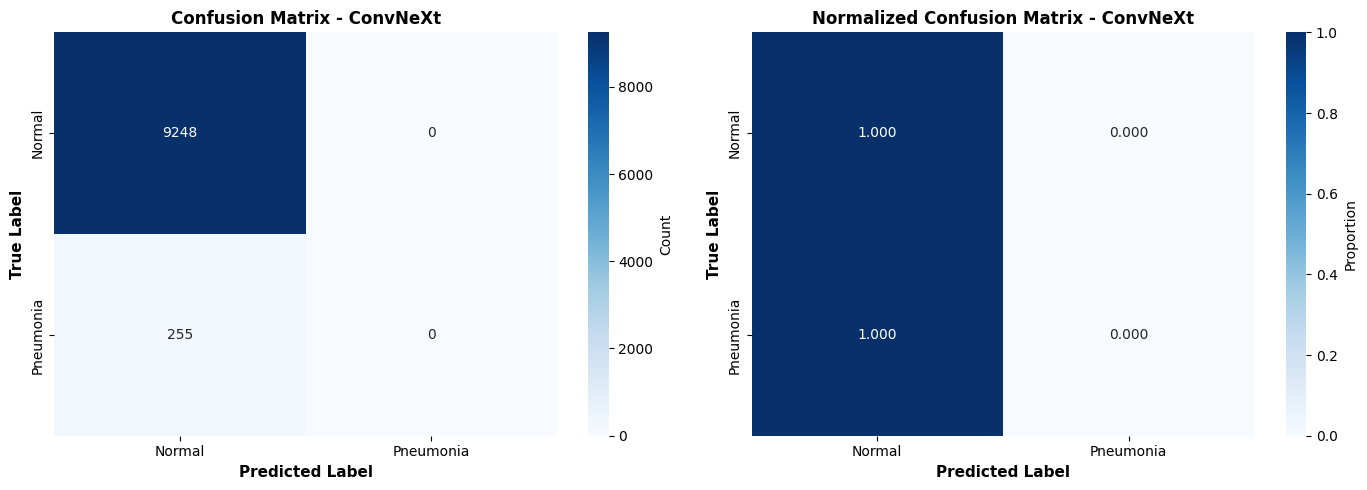

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Plot 1: Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'],
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_ylabel('True Label', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
axes[0].set_title('Confusion Matrix - ConvNeXt', fontsize=12, fontweight='bold')
 
# Plot 2: Normalized Confusion Matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'],
            ax=axes[1], cbar_kws={'label': 'Proportion'})
axes[1].set_ylabel('True Label', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
axes[1].set_title('Normalized Confusion Matrix - ConvNeXt', fontsize=12, fontweight='bold')
 
plt.tight_layout()
plt.savefig('convnext_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

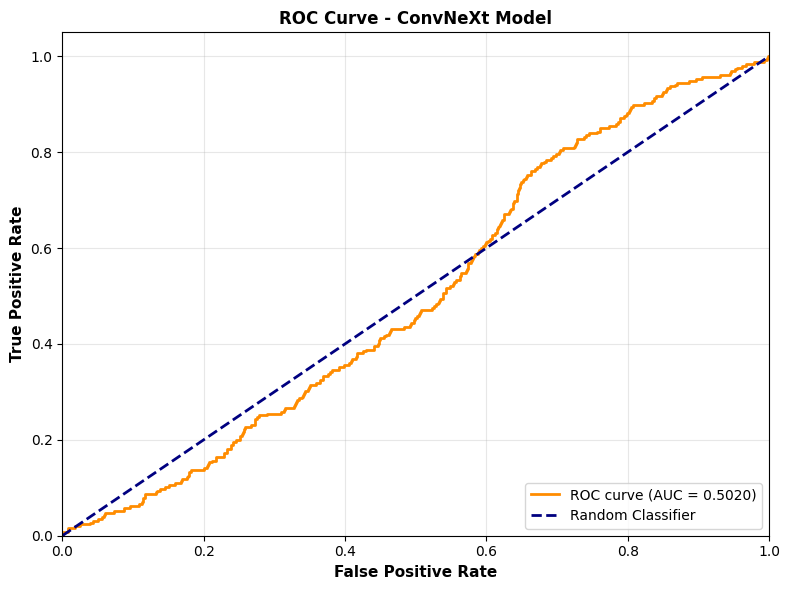

In [27]:
fig, ax = plt.subplots(figsize=(8, 6))
 
fpr, tpr, thresholds = roc_curve(test_labels, test_probs[:, 1])
roc_auc = auc(fpr, tpr)
 
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
ax.set_title('ROC Curve - ConvNeXt Model', fontsize=12, fontweight='bold')
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig('convnext_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

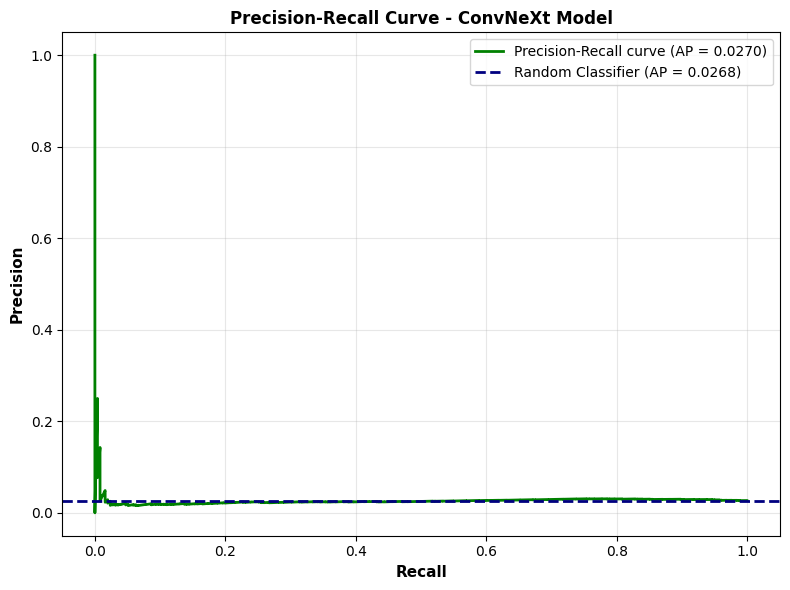


Metrics saved for XAI analysis!

CONVNEXT MODEL EVALUATION COMPLETE!


In [28]:
fig, ax = plt.subplots(figsize=(8, 6))
 
precision_vals, recall_vals, _ = precision_recall_curve(test_labels, test_probs[:, 1])
ap = average_precision_score(test_labels, test_probs[:, 1])
 
ax.plot(recall_vals, precision_vals, color='green', lw=2, 
        label=f'Precision-Recall curve (AP = {ap:.4f})')
ax.axhline(y=np.mean(test_labels), color='navy', linestyle='--', lw=2, 
           label=f'Random Classifier (AP = {np.mean(test_labels):.4f})')
ax.set_xlabel('Recall', fontsize=11, fontweight='bold')
ax.set_ylabel('Precision', fontsize=11, fontweight='bold')
ax.set_title('Precision-Recall Curve - ConvNeXt Model', fontsize=12, fontweight='bold')
ax.legend(loc="best", fontsize=10)
ax.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig('convnext_precision_recall_curve.png', dpi=300, bbox_inches='tight')
plt.show()
 
print("\nMetrics saved for XAI analysis!")
 
print("\n" + "="*70)
print("CONVNEXT MODEL EVALUATION COMPLETE!")
print("="*70)


Plotting training curves...



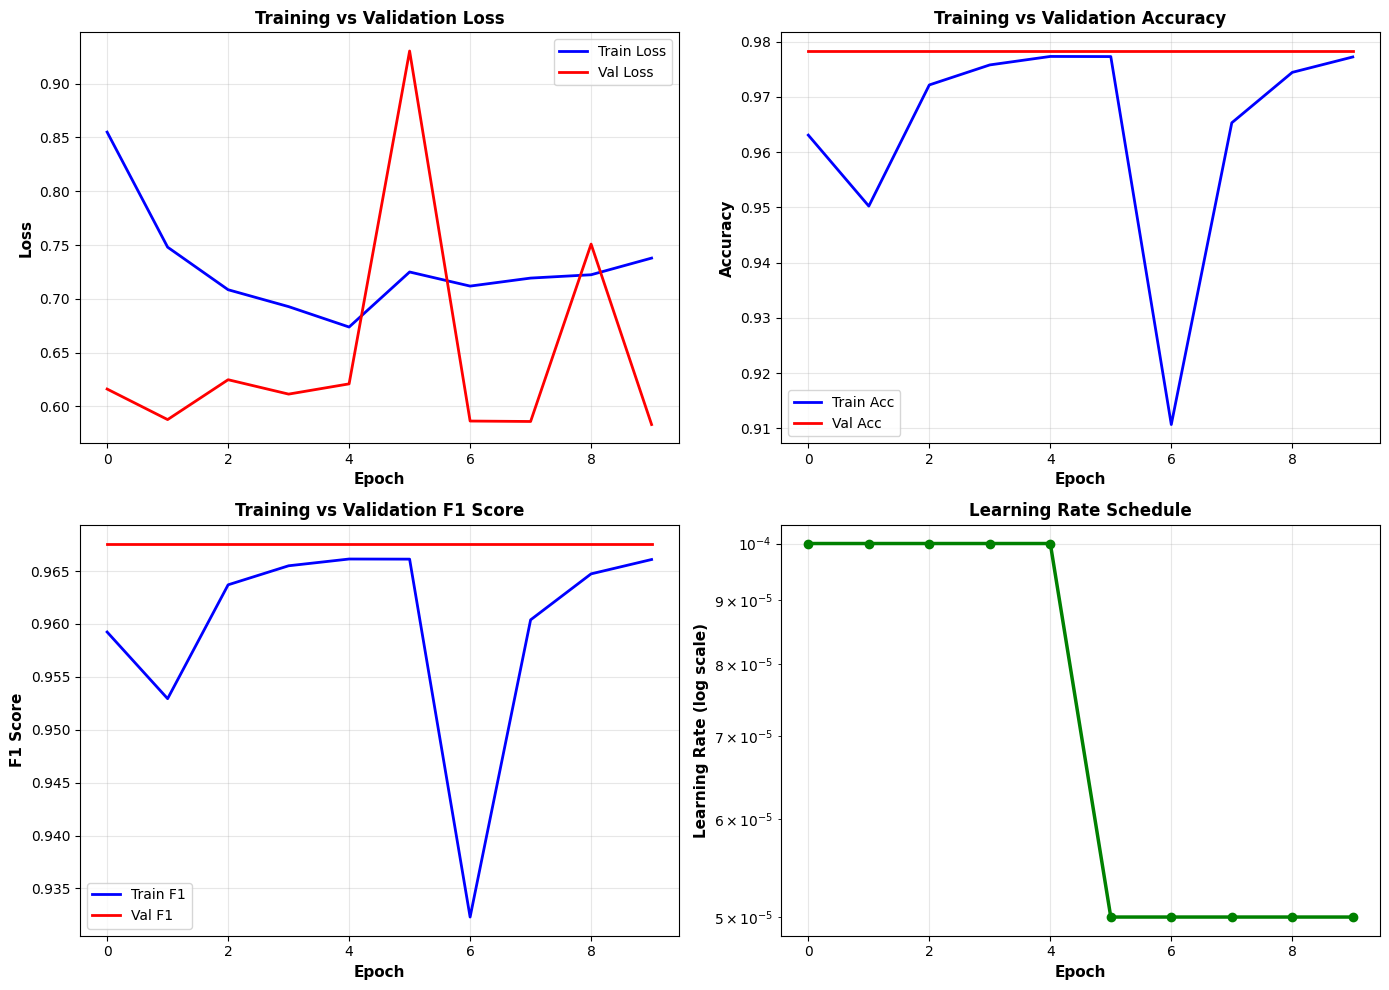

✓ Training curves saved: convnext_training_curves.png


In [29]:
# =============================================================================
# CELL: CONVNEXT TRAINING CURVES
# =============================================================================

print("\nPlotting training curves...\n")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Train vs Val Loss
axes[0, 0].plot(history['train_loss'], 'b-', label='Train Loss', linewidth=2)
axes[0, 0].plot(history['val_loss'], 'r-', label='Val Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Loss', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Training vs Validation Loss', fontsize=12, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Train vs Val Accuracy
axes[0, 1].plot(history['train_acc'], 'b-', label='Train Acc', linewidth=2)
axes[0, 1].plot(history['val_acc'], 'r-', label='Val Acc', linewidth=2)
axes[0, 1].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Accuracy', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Training vs Validation Accuracy', fontsize=12, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Train vs Val F1 Score
axes[1, 0].plot(history['train_f1'], 'b-', label='Train F1', linewidth=2)
axes[1, 0].plot(history['val_f1'], 'r-', label='Val F1', linewidth=2)
axes[1, 0].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('F1 Score', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Training vs Validation F1 Score', fontsize=12, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Learning Rate Schedule
axes[1, 1].semilogy(history['learning_rates'], 'g-', linewidth=2.5, marker='o')
axes[1, 1].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Learning Rate (log scale)', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Learning Rate Schedule', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('convnext_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Training curves saved: convnext_training_curves.png")

# Grad Cam

Initializing Grad-CAM...
Loading test samples for Grad-CAM...
Test batch shape: torch.Size([32, 3, 224, 224])
Test labels shape: (32,)

Generating Grad-CAM for 6 samples...

Sample 1/6: True=0, Pred=0, Conf=0.731
Sample 2/6: True=0, Pred=0, Conf=0.732
Sample 3/6: True=0, Pred=0, Conf=0.739
Sample 4/6: True=0, Pred=0, Conf=0.703
Sample 5/6: True=0, Pred=0, Conf=0.703
Sample 6/6: True=0, Pred=0, Conf=0.687


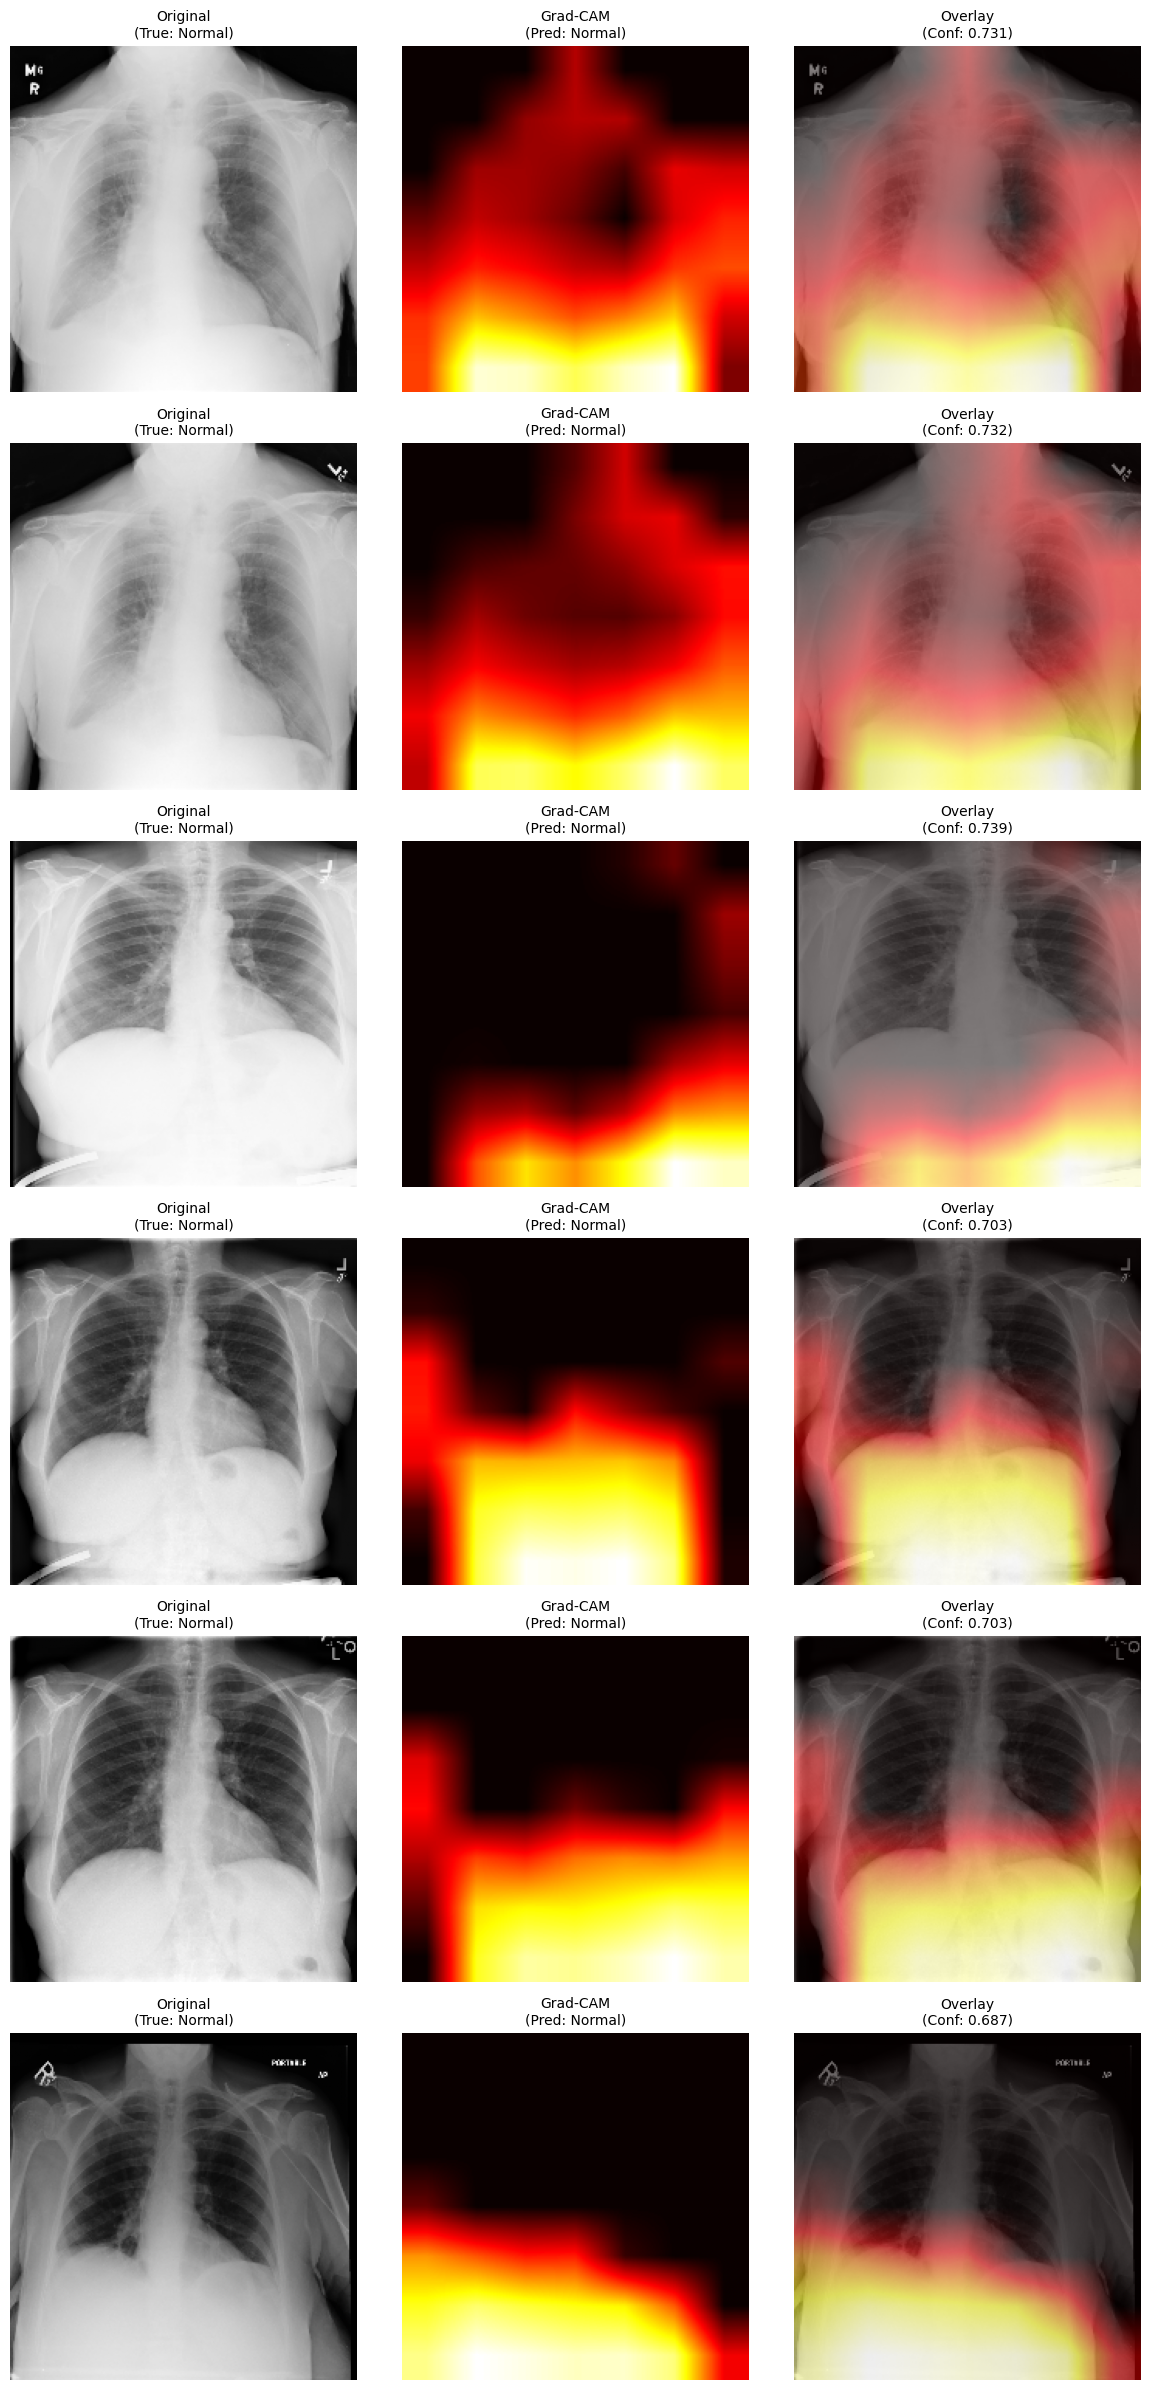


✓ Grad-CAM visualizations complete!
✓ Output: convnext_gradcam_visualizations.png


In [30]:
# =============================================================================
# CELL: CONVNEXT GRAD-CAM VISUALIZATION
# =============================================================================

import torch.nn.functional as F
import cv2

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register hooks
        target_layer.register_forward_hook(self._save_activations)
        target_layer.register_full_backward_hook(self._save_gradients)
    
    def _save_activations(self, module, input, output):
        self.activations = output.detach()
    
    def _save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate_cam(self, input_tensor, class_idx=None):
        batch_size, channels, height, width = input_tensor.size()
        
        # Forward pass
        logits = self.model(input_tensor)
        
        if class_idx is None:
            class_idx = logits.argmax(dim=1)
        
        self.model.zero_grad()
        
        # Backward pass
        one_hot = torch.zeros_like(logits)
        one_hot.scatter_(1, class_idx.view(-1, 1), 1.0)
        logits.backward(gradient=one_hot, retain_graph=True)
        
        # Generate CAM
        if len(self.gradients.shape) == 4:
            gradients = self.gradients[0]
            activations = self.activations[0]
        elif len(self.gradients.shape) == 3:
            gradients = self.gradients
            activations = self.activations
        else:
            raise ValueError(f"Unexpected gradient shape: {self.gradients.shape}")
        
        # Average pooling over spatial dimensions
        weights = gradients.mean(dim=(1, 2), keepdim=True)
        weighted_activations = weights * activations
        cam = weighted_activations.sum(dim=0)
        
        # Normalize
        cam = F.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        
        return cam.cpu().numpy()

# Initialize Grad-CAM with ConvNeXt features layer
print("Initializing Grad-CAM...")
grad_cam = GradCAM(model, model.features[-1])

# Get some test samples
print("Loading test samples for Grad-CAM...")
test_images_batch = None
test_labels_batch = None
test_probs_batch = None

for images, labels in test_gen.take(1):
    images = preprocess_images(images)
    labels = preprocess_labels(labels)
    
    test_images_batch = images
    test_labels_batch = labels.numpy()
    
    with torch.no_grad():
        images_device = images.to(device)
        outputs = model(images_device)
        test_probs_batch = torch.softmax(outputs, dim=1).cpu().numpy()
    break

print(f"Test batch shape: {test_images_batch.shape}")
print(f"Test labels shape: {test_labels_batch.shape}")

# Visualize Grad-CAM
num_samples = min(6, len(test_images_batch))
fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4*num_samples))

if num_samples == 1:
    axes = axes.reshape(1, -1)

print(f"\nGenerating Grad-CAM for {num_samples} samples...\n")

for idx in range(num_samples):
    # Get image
    img = test_images_batch[idx].numpy()
    
    # Convert from (3, H, W) to (H, W, 3) for visualization
    img_normalized = np.transpose(img, (1, 2, 0))
    
    # Normalize to 0-1
    img_normalized = (img_normalized - img_normalized.min()) / (img_normalized.max() - img_normalized.min() + 1e-8)
    
    # For grayscale display, take mean across channels
    img_gray = img_normalized.mean(axis=2)
    
    # Get prediction
    true_label = test_labels_batch[idx]
    pred_label = np.argmax(test_probs_batch[idx])
    confidence = test_probs_batch[idx][pred_label]
    
    print(f"Sample {idx+1}/{num_samples}: True={int(true_label)}, Pred={int(pred_label)}, Conf={confidence:.3f}")
    
    # Generate Grad-CAM
    try:
        # Create batch with single image
        img_tensor = test_images_batch[idx:idx+1].to(device)
        cam = grad_cam.generate_cam(img_tensor, torch.tensor([pred_label], device=device))
        
        # Resize CAM to match image size if needed
        if cam.shape != img_gray.shape:
            cam = cv2.resize(cam, (img_gray.shape[1], img_gray.shape[0]))
        
        # Plot original image
        axes[idx, 0].imshow(img_gray, cmap='gray')
        axes[idx, 0].set_title(f'Original\n(True: {"Pneumonia" if true_label else "Normal"})', fontsize=10)
        axes[idx, 0].axis('off')
        
        # Plot Grad-CAM
        axes[idx, 1].imshow(cam, cmap='hot')
        axes[idx, 1].set_title(f'Grad-CAM\n(Pred: {"Pneumonia" if pred_label else "Normal"})', fontsize=10)
        axes[idx, 1].axis('off')
        
        # Plot overlay
        axes[idx, 2].imshow(img_gray, cmap='gray')
        axes[idx, 2].imshow(cam, cmap='hot', alpha=0.5)
        axes[idx, 2].set_title(f'Overlay\n(Conf: {confidence:.3f})', fontsize=10)
        axes[idx, 2].axis('off')
        
    except Exception as e:
        print(f"Error generating CAM for sample {idx+1}: {e}")

plt.tight_layout()
plt.savefig('convnext_gradcam_visualizations.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Grad-CAM visualizations complete!")
print("✓ Output: convnext_gradcam_visualizations.png")

# Lime

Initializing LIME explainer...
Generating LIME explanation...


  0%|          | 0/1000 [00:00<?, ?it/s]

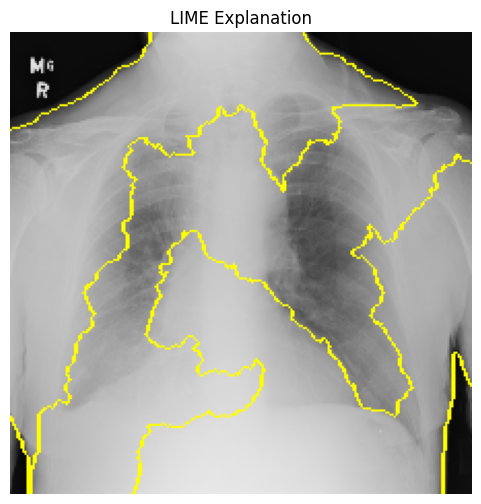

✓ LIME complete


In [31]:
# =============================================================================
# CELL: LIME IMAGE EXPLANATION
# =============================================================================

import lime
import lime.lime_image
from skimage.segmentation import mark_boundaries

print("Initializing LIME explainer...")

explainer = lime.lime_image.LimeImageExplainer()

def lime_predict(images):
    """
    LIME expects numpy input (H, W, C) → batch
    We convert to torch format and run model
    """
    images = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)
    
    if images.max() > 1:
        images = images / 255.0

    with torch.no_grad():
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
    
    return probs


# Get one sample
img = test_images_batch[0].numpy()
img = np.transpose(img, (1, 2, 0))  # CHW → HWC

print("Generating LIME explanation...")

explanation = explainer.explain_instance(
    img,
    lime_predict,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=5,
    hide_rest=False
)

plt.figure(figsize=(6,6))
plt.imshow(mark_boundaries(temp, mask))
plt.title("LIME Explanation")
plt.axis("off")
plt.show()

print("✓ LIME complete")

# PDP

Computing PDP...


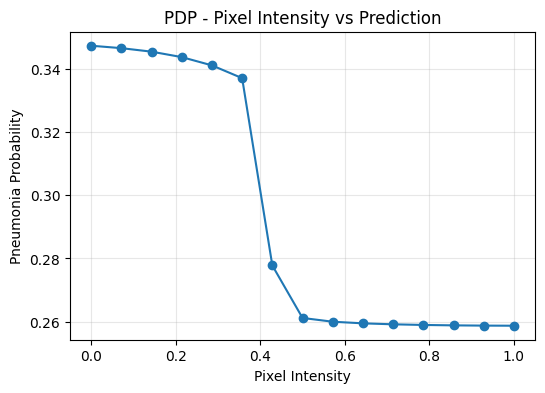

✓ PDP complete


In [32]:
# =============================================================================
# CELL: PDP (PIXEL INTENSITY EFFECT)
# =============================================================================

print("Computing PDP...")

def predict_single(img):
    img_tensor = torch.tensor(img).permute(2,0,1).unsqueeze(0).float().to(device)
    
    if img_tensor.max() > 1:
        img_tensor = img_tensor / 255.0

    with torch.no_grad():
        output = model(img_tensor)
        prob = torch.softmax(output, dim=1)[0,1].item()
    
    return prob


# Use one test image
base_img = test_images_batch[0].numpy()
base_img = np.transpose(base_img, (1,2,0))  # CHW → HWC

values = np.linspace(0, 1, 15)
preds = []

for v in values:
    temp = base_img.copy()
    
    # perturb brightness (all channels)
    temp[:,:,0] = v
    temp[:,:,1] = v
    temp[:,:,2] = v
    
    preds.append(predict_single(temp))


plt.figure(figsize=(6,4))
plt.plot(values, preds, marker='o')
plt.title("PDP - Pixel Intensity vs Prediction")
plt.xlabel("Pixel Intensity")
plt.ylabel("Pneumonia Probability")
plt.grid(True, alpha=0.3)
plt.show()

print("✓ PDP complete")

# Ice

Computing ICE plots...


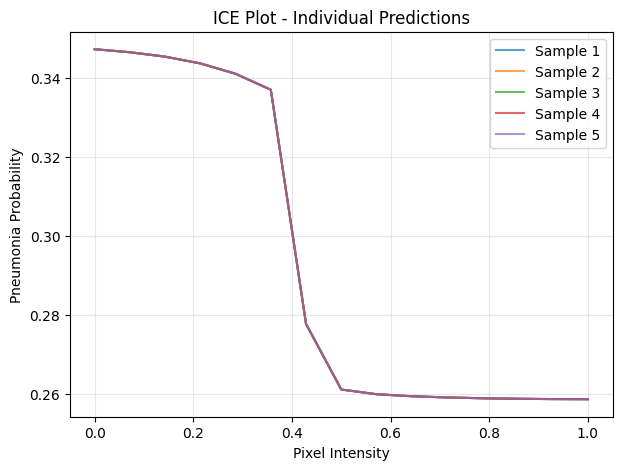

✓ ICE complete


In [33]:
# =============================================================================
# CELL: ICE (INDIVIDUAL CONDITIONAL EXPECTATION)
# =============================================================================

print("Computing ICE plots...")

num_samples = 5
values = np.linspace(0, 1, 15)

plt.figure(figsize=(7,5))

for i in range(num_samples):
    img = test_images_batch[i].numpy()
    img = np.transpose(img, (1,2,0))  # CHW → HWC
    
    preds = []
    
    for v in values:
        temp = img.copy()
        temp[:,:,0] = v
        temp[:,:,1] = v
        temp[:,:,2] = v
        
        preds.append(predict_single(temp))
    
    plt.plot(values, preds, alpha=0.7, label=f"Sample {i+1}")

plt.title("ICE Plot - Individual Predictions")
plt.xlabel("Pixel Intensity")
plt.ylabel("Pneumonia Probability")
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

print("✓ ICE complete")